In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [14]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Cow Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Check classes
print(train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)

Found 796 images belonging to 3 classes.
Found 199 images belonging to 3 classes.
{'Healthy cows': 0, 'foot and mouth': 1, 'lumpy': 2}
Number of classes: 3


In [4]:
VGG16

<function keras.src.applications.vgg16.VGG16(include_top=True, weights='imagenet', input_tensor=None, input_shape=None, pooling=None, classes=1000, classifier_activation='softmax', name='vgg16')>

In [15]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Fine-tune last layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# AUTO class count (important)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [18]:
epochs = 15

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.4535 - loss: 1.8645 - val_accuracy: 0.6935 - val_loss: 0.7172 - learning_rate: 5.0000e-05
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 117s 5s/step - accuracy: 0.6771 - loss: 0.7617 - val_accuracy: 0.7638 - val_loss: 0.5674 - learning_rate: 5.0000e-05
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.7500 - loss: 0.6384 - val_accuracy: 0.8392 - val_loss: 0.4433 - learning_rate: 5.0000e-05
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.8065 - loss: 0.5017 - val_accuracy: 0.8291 - val_loss: 0.4163 - learning_rate: 5.0000e-05
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 116s 5s/step - accuracy: 0.8417 - loss: 0.4431 - val_accuracy: 0.8593 - val_loss: 0.3666 - learning_rate: 5.0000e-05
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 115s 5s/step - accuracy: 0.8681 - loss: 0.4065 - val_accuracy: 0.8492 - val_loss: 0.3540 - learning_rate: 5.0000e-05
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.8643 

In [19]:
loss, accuracy = model.evaluate(validation_generator)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9397 - loss: 0.2204
Validation Loss: 0.22037990391254425
Validation Accuracy: 0.9396985173225403


7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step


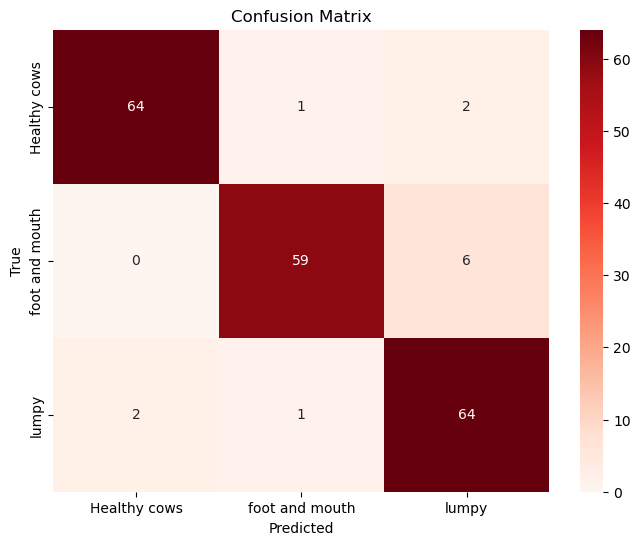

                precision    recall  f1-score   support

  Healthy cows       0.97      0.96      0.96        67
foot and mouth       0.97      0.91      0.94        65
         lumpy       0.89      0.96      0.92        67

      accuracy                           0.94       199
     macro avg       0.94      0.94      0.94       199
  weighted avg       0.94      0.94      0.94       199



In [20]:
validation_generator.reset()

predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Reds',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

In [23]:
metrics_dict = {}
class_names = list(validation_generator.class_indices.keys())

for i, class_name in enumerate(class_names):
    TP = confusion_mtx[i, i]
    FP = confusion_mtx[:, i].sum() - TP
    FN = confusion_mtx[i, :].sum() - TP
    TN = confusion_mtx.sum() - (TP + FP + FN)
    
    metrics_dict[class_name] = {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN
    }

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

                TP  FP  FN   TN
Healthy cows    64   2   3  130
foot and mouth  59   2   6  132
lumpy           64   8   3  124


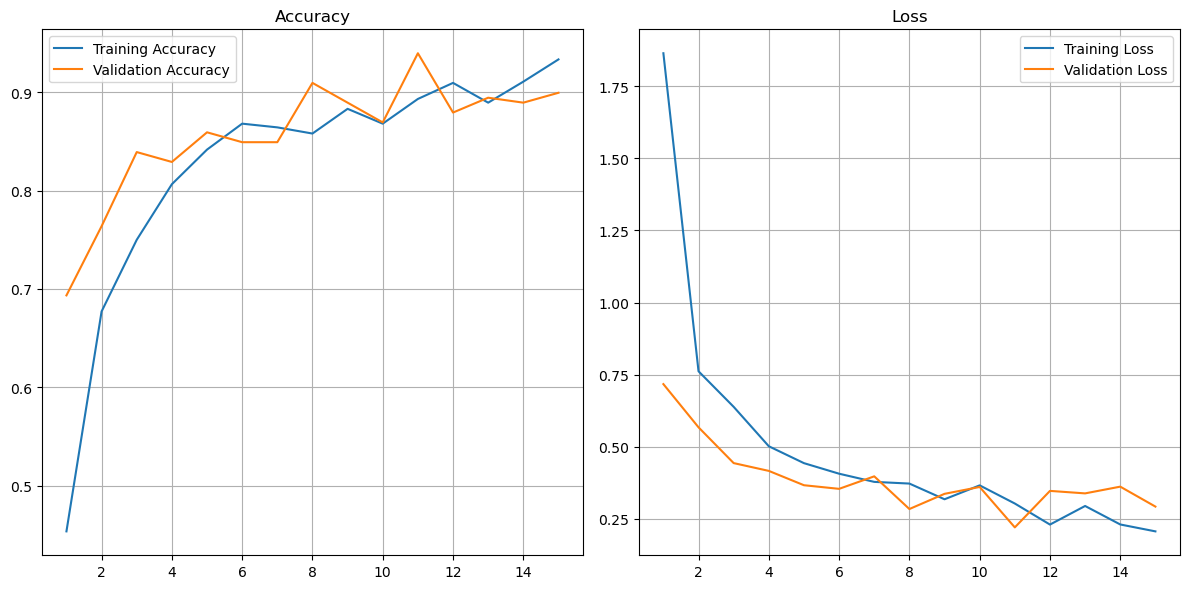

In [24]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
model.save('AImodel_VGG16_Cow.keras')

In [26]:
model.save('AImodel_VGG16_Cow.h5')

In [ ]:
ResNet50

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2   


from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [2]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Cow Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.4,
    horizontal_flip=True,
    shear_range=0.3,
    brightness_range=[0.6, 1.4],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 795 images belonging to 3 classes.
Found 198 images belonging to 3 classes.


In [9]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

# Fine-tune last layers
for layer in base_model.layers[-15:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

# L2 USED HERE
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)

x = Dropout(0.6)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model_RESNET = Model(inputs=base_model.input, outputs=output)

In [10]:
model_RESNET.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [12]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9888059701492538), 1: np.float64(1.003787878787879), 2: np.float64(1.0076045627376427)}


In [13]:
history_resnet = model_RESNET.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights   
)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3572 - loss: 2.0214 - val_accuracy: 0.5101 - val_loss: 1.2080 - learning_rate: 1.0000e-05
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.4365 - loss: 1.6403 - val_accuracy: 0.6919 - val_loss: 1.0364 - learning_rate: 1.0000e-05
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.4453 - loss: 1.4901 - val_accuracy: 0.7273 - val_loss: 0.9409 - learning_rate: 1.0000e-05
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5119 - loss: 1.4197 - val_accuracy: 0.7677 - val_loss: 0.8684 - learning_rate: 1.0000e-05
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5711 - loss: 1.2540 - val_accuracy: 0.7929 - val_loss: 0.8190 - learning_rate: 1.0000e-05
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.6013 - loss: 1.1710 - val_accuracy: 0.8283 - val_loss: 0.7775 - learning_rate: 1.0000e-05
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5975 - loss:

In [14]:
loss, accuracy = model_RESNET.evaluate(validation_generator)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 773ms/step - accuracy: 0.8788 - loss: 0.5459
Validation Loss: 0.5458932518959045
Validation Accuracy: 0.8787878751754761


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 951ms/step


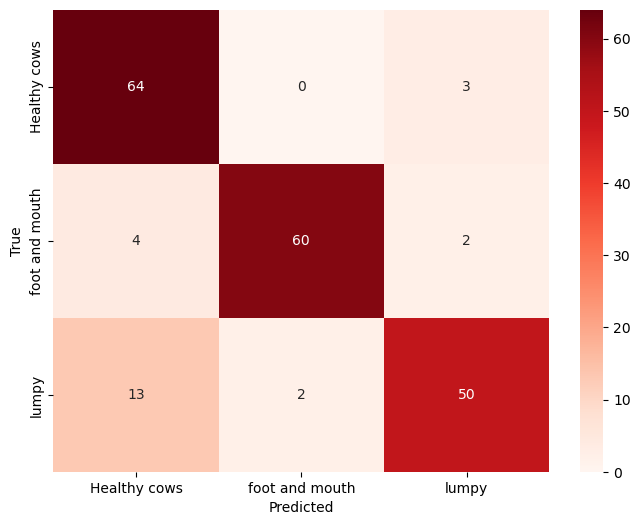

                precision    recall  f1-score   support

  Healthy cows       0.79      0.96      0.86        67
foot and mouth       0.97      0.91      0.94        66
         lumpy       0.91      0.77      0.83        65

      accuracy                           0.88       198
     macro avg       0.89      0.88      0.88       198
  weighted avg       0.89      0.88      0.88       198



In [15]:
validation_generator.reset()

predictions = model_RESNET.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Reds',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

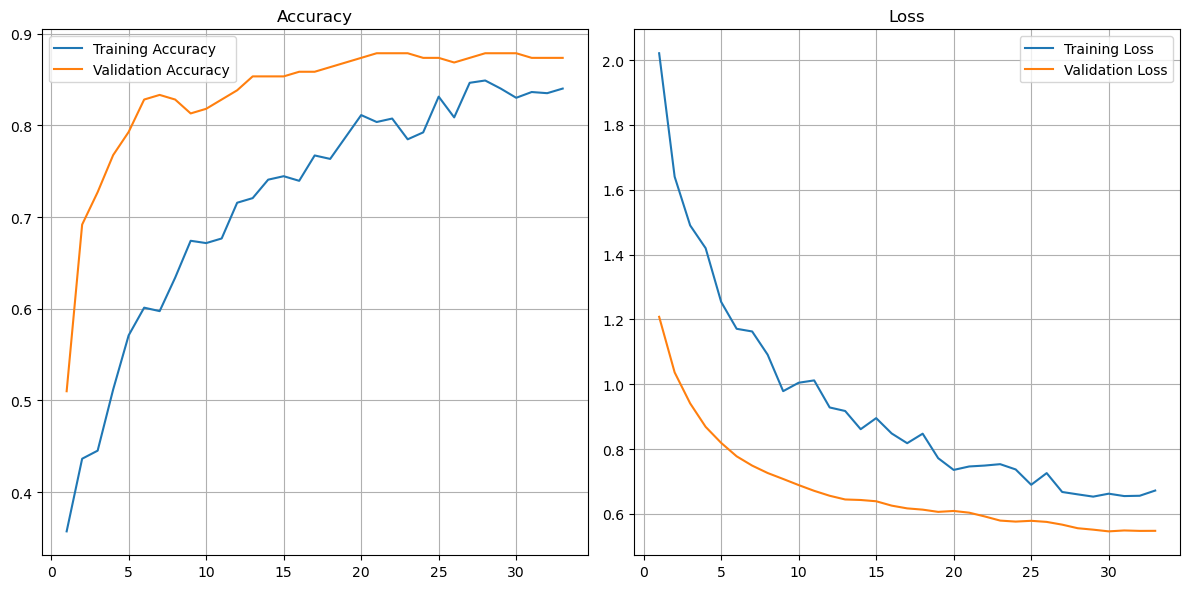

In [16]:
training_accuracy = history_resnet.history['accuracy']
validation_accuracy = history_resnet.history['val_accuracy']
training_loss = history_resnet.history['loss']
validation_loss = history_resnet.history['val_loss']

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
model_RESNET.save('AImodelResnet_FINAL.keras')

In [ ]:
DenseNet121

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [22]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Cow Dataset'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.4,
    horizontal_flip=True,
    shear_range=0.3,
    brightness_range=[0.6, 1.4],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 795 images belonging to 3 classes.
Found 198 images belonging to 3 classes.


In [23]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9888059701492538), 1: np.float64(1.003787878787879), 2: np.float64(1.0076045627376427)}


In [24]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Unfreeze last layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

# L2 added
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)

x = Dropout(0.6)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

densenet_model = Model(inputs=base_model.input, outputs=output)

In [25]:
densenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),   
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [27]:
history_densenet = densenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3610 - loss: 2.0469 - val_accuracy: 0.4293 - val_loss: 1.3690 - learning_rate: 1.0000e-05
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3623 - loss: 1.9583 - val_accuracy: 0.4747 - val_loss: 1.2560 - learning_rate: 1.0000e-05
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3950 - loss: 1.8183 - val_accuracy: 0.4899 - val_loss: 1.1897 - learning_rate: 1.0000e-05
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3799 - loss: 1.8145 - val_accuracy: 0.5253 - val_loss: 1.1421 - learning_rate: 1.0000e-05
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.3975 - loss: 1.6555 - val_accuracy: 0.5253 - val_loss: 1.1078 - learning_rate: 1.0000e-05
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3937 - loss: 1.7499 - val_accuracy: 0.5657 - val_loss: 1.0761 - learning_rate: 1.0000e-05
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4214 - loss:

In [28]:
loss, accuracy = densenet_model.evaluate(validation_generator)

print("DenseNet121 Validation Loss:", loss)
print("DenseNet121 Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 836ms/step - accuracy: 0.7778 - loss: 0.7165
DenseNet121 Validation Loss: 0.7165384292602539
DenseNet121 Validation Accuracy: 0.7777777910232544


7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


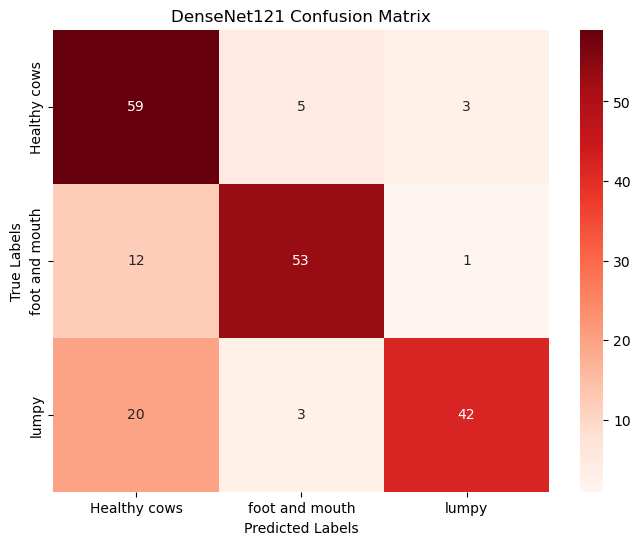

                precision    recall  f1-score   support

  Healthy cows       0.65      0.88      0.75        67
foot and mouth       0.87      0.80      0.83        66
         lumpy       0.91      0.65      0.76        65

      accuracy                           0.78       198
     macro avg       0.81      0.78      0.78       198
  weighted avg       0.81      0.78      0.78       198



In [29]:
# Reset generator
validation_generator.reset()

# Predictions
predictions = densenet_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = validation_generator.classes

# Confusion matrix
confusion_mtx = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Reds',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('DenseNet121 Confusion Matrix')
plt.show()

# Classification report
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=validation_generator.class_indices.keys()
))

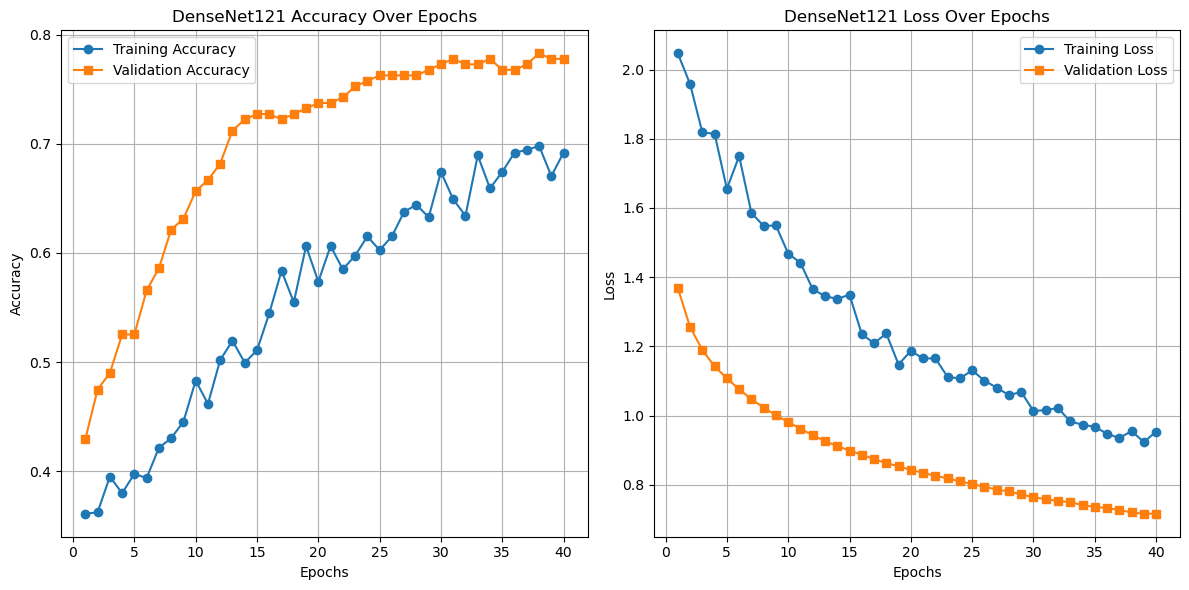

In [30]:
# Extract training history
training_accuracy = history_densenet.history['accuracy']
validation_accuracy = history_densenet.history['val_accuracy']
training_loss = history_densenet.history['loss']
validation_loss = history_densenet.history['val_loss']

 epochs_range = range(1, len(training_accuracy) + 1)

# Plot accuracy and loss
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy', marker='s')
plt.title('DenseNet121 Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss', marker='o')
plt.plot(epochs_range, validation_loss, label='Validation Loss', marker='s')
plt.title('DenseNet121 Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
densenet_model.save('AImodelDenseNet121.keras')

In [32]:
MobileNetV2

NameError: name 'MobileNetV2' is not defined

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [34]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Cow Dataset'

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation generator without augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 795 images belonging to 3 classes.
Found 198 images belonging to 3 classes.


In [35]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Better than Flatten
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

In [36]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

epochs = 40

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 548ms/step - accuracy: 0.4013 - loss: 1.2969 - val_accuracy: 0.5960 - val_loss: 0.8900
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 491ms/step - accuracy: 0.5522 - loss: 0.9825 - val_accuracy: 0.6869 - val_loss: 0.7295
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 496ms/step - accuracy: 0.6252 - loss: 0.8430 - val_accuracy: 0.7222 - val_loss: 0.6621
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 498ms/step - accuracy: 0.6830 - loss: 0.7706 - val_accuracy: 0.7576 - val_loss: 0.5982
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 503ms/step - accuracy: 0.7132 - loss: 0.6893 - val_accuracy: 0.7424 - val_loss: 0.6114
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 500ms/step - accuracy: 0.7472 - loss: 0.6517 - val_accuracy: 0.8182 - val_loss: 0.5389
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 506ms/step - accuracy: 0.7434 - loss: 0.6389 - val_accuracy: 0.7778 - val_loss: 0.5287
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 502ms/step - accuracy: 0.7660 - loss: 0.5675 - val_accu

In [38]:
loss, accuracy = mobilenet_model.evaluate(validation_generator)
print("MobileNetV2 Validation Loss:", loss)
print("MobileNetV2 Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.8889 - loss: 0.3386
MobileNetV2 Validation Loss: 0.3385860025882721
MobileNetV2 Validation Accuracy: 0.8888888955116272


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 402ms/step


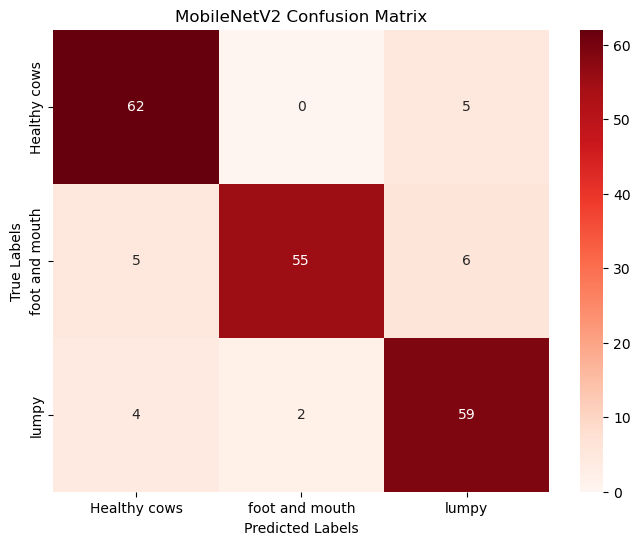

In [39]:
validation_generator.reset()
predictions = mobilenet_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Reds',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

In [40]:
print("MobileNetV2 Classification Report:")
print(classification_report(true_classes, predicted_classes,
                            target_names=validation_generator.class_indices.keys()))

MobileNetV2 Classification Report:
                precision    recall  f1-score   support

  Healthy cows       0.87      0.93      0.90        67
foot and mouth       0.96      0.83      0.89        66
         lumpy       0.84      0.91      0.87        65

      accuracy                           0.89       198
     macro avg       0.89      0.89      0.89       198
  weighted avg       0.89      0.89      0.89       198



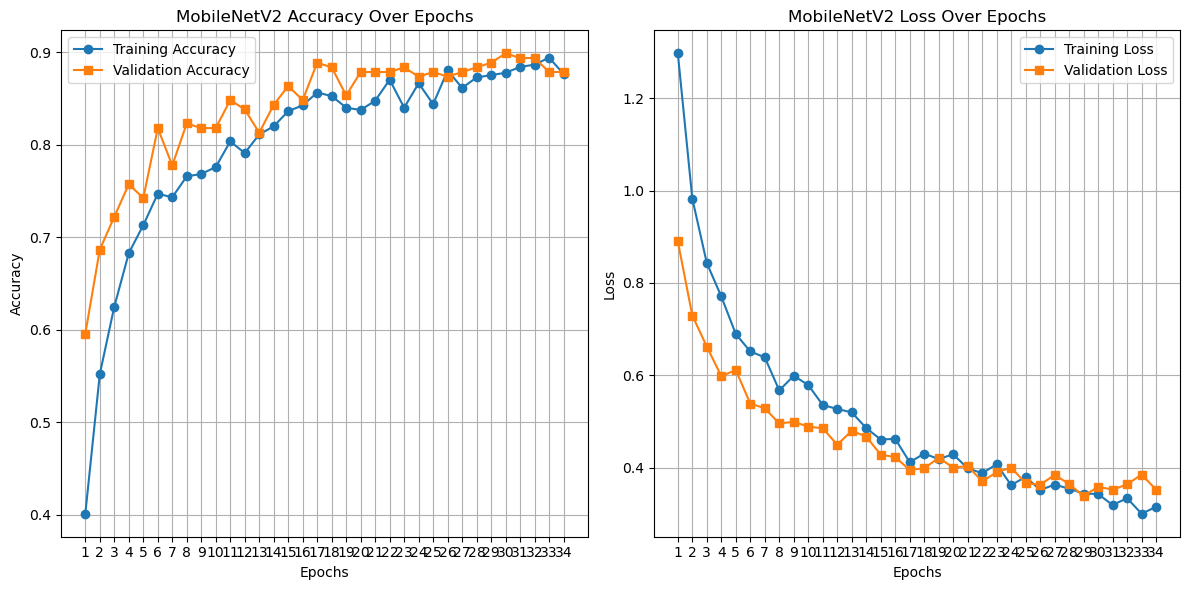

In [41]:
training_accuracy = history_mobilenet.history['accuracy']
validation_accuracy = history_mobilenet.history['val_accuracy']
training_loss = history_mobilenet.history['loss']
validation_loss = history_mobilenet.history['val_loss']
epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy', marker='s')
plt.title('MobileNetV2 Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss', marker='o')
plt.plot(epochs_range, validation_loss, label='Validation Loss', marker='s')
plt.title('MobileNetV2 Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [42]:
mobilenet_model.save('AImodelMobileNetV2.keras')

In [ ]:
Vision Transformer (ViT)

In [43]:
!pip install vit-keras
!pip install opencv-python

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vit_keras import vit
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

In [45]:
data_folder = '/Users/muhammadtaha/Desktop/Computer Science Project by Muhammad Taha Iqbal/Dataset/Cow Dataset'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    data_folder,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 795 images belonging to 3 classes.
Found 198 images belonging to 3 classes.


In [46]:
# Load pretrained ViT base model without the top classifier
vit_model = vit.vit_b16(
    image_size=224,
    pretrained=True,
    include_top=False,
    pretrained_top=False
)

# Freeze base ViT layers
for layer in vit_model.layers:
    layer.trainable = False

# Add custom classifier directly
x = vit_model.output  # shape: (batch_size, 768)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

# Create final model
vit_final_model = Model(inputs=vit_model.input, outputs=output)

/opt/anaconda3/envs/LiveStock-HealthMangmentSystem/lib/python3.11/site-packages/vit_keras/utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


In [47]:
vit_final_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

epochs = 40

history_vit = vit_final_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 195s 8s/step - accuracy: 0.3912 - loss: 1.5288 - val_accuracy: 0.4646 - val_loss: 1.0448
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 184s 7s/step - accuracy: 0.4868 - loss: 1.2201 - val_accuracy: 0.6162 - val_loss: 0.8408
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 184s 7s/step - accuracy: 0.5547 - loss: 1.0523 - val_accuracy: 0.6616 - val_loss: 0.7446
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 185s 7s/step - accuracy: 0.6327 - loss: 0.9047 - val_accuracy: 0.6919 - val_loss: 0.6640
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 184s 7s/step - accuracy: 0.6667 - loss: 0.8295 - val_accuracy: 0.6818 - val_loss: 0.6479
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 185s 7s/step - accuracy: 0.6868 - loss: 0.7824 - val_accuracy: 0.7273 - val_loss: 0.5965
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 185s 7s/step - accuracy: 0.6805 - loss: 0.7661 - val_accuracy: 0.7475 - val_loss: 0.5644
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 185s 8s/step - accuracy: 0.6918 - loss: 0.7552 - val_accuracy: 0.7828 - v

In [49]:
loss, accuracy = vit_final_model.evaluate(validation_generator)
print("ViT Validation Loss:", loss)
print("ViT Validation Accuracy:", accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 5s/step - accuracy: 0.8535 - loss: 0.3662
ViT Validation Loss: 0.3661523163318634
ViT Validation Accuracy: 0.8535353541374207


7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step


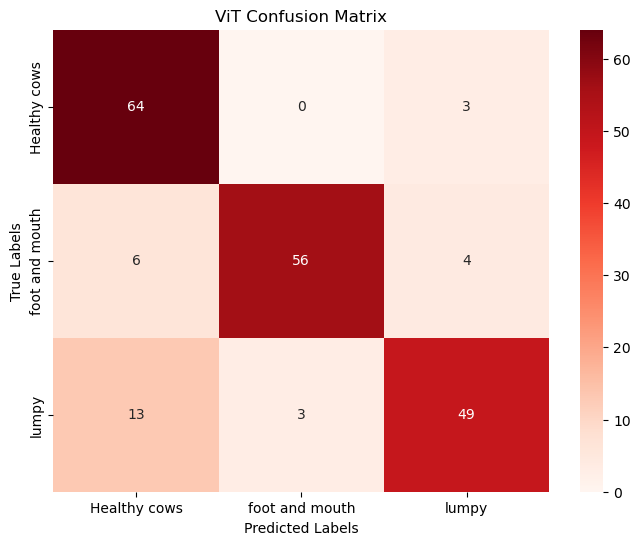

In [50]:
validation_generator.reset()
predictions = vit_final_model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

confusion_mtx = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Reds',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('ViT Confusion Matrix')
plt.show()

In [51]:
print("ViT Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=validation_generator.class_indices.keys()))

ViT Classification Report:
                precision    recall  f1-score   support

  Healthy cows       0.77      0.96      0.85        67
foot and mouth       0.95      0.85      0.90        66
         lumpy       0.88      0.75      0.81        65

      accuracy                           0.85       198
     macro avg       0.87      0.85      0.85       198
  weighted avg       0.86      0.85      0.85       198



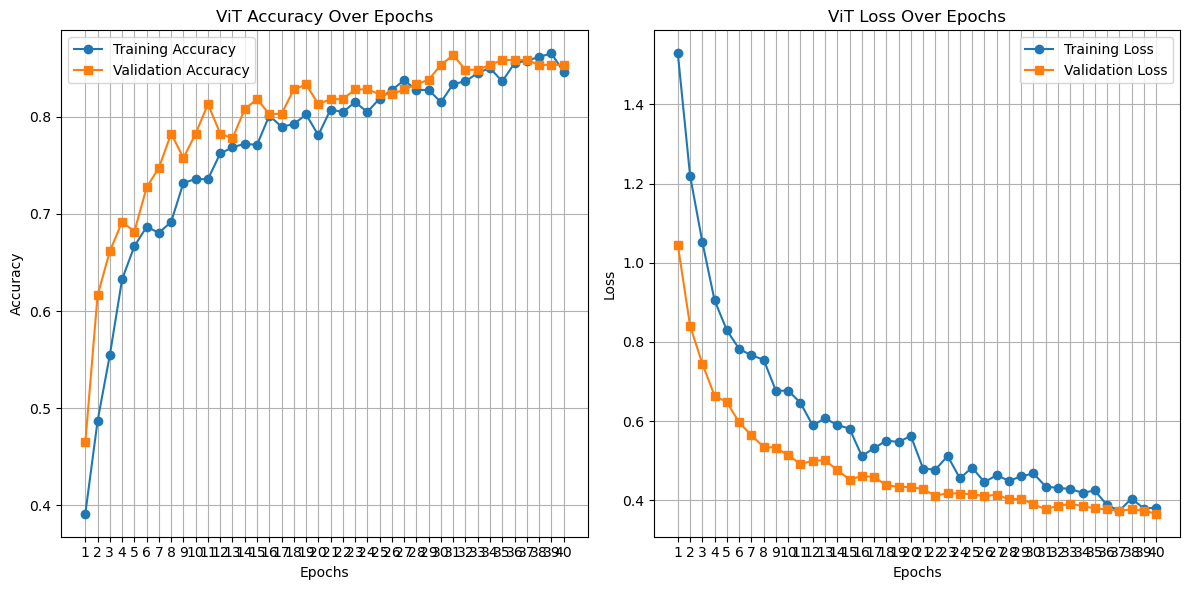

In [52]:
training_accuracy = history_vit.history['accuracy']
validation_accuracy = history_vit.history['val_accuracy']
training_loss = history_vit.history['loss']
validation_loss = history_vit.history['val_loss']
epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(12, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy', marker='s')
plt.title('ViT Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label='Training Loss', marker='o')
plt.plot(epochs_range, validation_loss, label='Validation Loss', marker='s')
plt.title('ViT Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [53]:
vit_final_model.save('AImodelViT.keras')